# Phase 1 — Data Cleaning & Exploratory Analysis

## 0. Imports & config

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os

os.chdir('..')
RAW = Path('data/raw')
OUT = Path('data')
OUT.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Load raw tables

In [6]:
orders       = pd.read_csv(RAW / 'olist_orders_dataset.csv')
order_items  = pd.read_csv(RAW / 'olist_order_items_dataset.csv')
order_pays   = pd.read_csv(RAW / 'olist_order_payments_dataset.csv')
order_revs   = pd.read_csv(RAW / 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(RAW / 'olist_products_dataset.csv')
product_cats = pd.read_csv(RAW / 'product_category_name_translation.csv')
sellers      = pd.read_csv(RAW / 'olist_sellers_dataset.csv')
customers    = pd.read_csv(RAW / 'olist_customers_dataset.csv')
geo          = pd.read_csv(RAW / 'olist_geolocation_dataset.csv')

print('Tables loaded:')
for name, df in [
    ('orders', orders), ('order_items', order_items), ('order_pays', order_pays),
    ('order_revs', order_revs), ('products', products), ('sellers', sellers),
    ('customers', customers)
]:
    print(f'  {name:20s} {df.shape}')

Tables loaded:
  orders               (99441, 8)
  order_items          (112650, 7)
  order_pays           (103886, 5)
  order_revs           (99224, 7)
  products             (32951, 9)
  sellers              (3095, 4)
  customers            (99441, 5)


## 2. Clean individual tables

In [7]:
# ── Orders: parse all datetime columns ──────────────────────────────────────
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders (exclude cancelled, unavailable)
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(orders_clean):,}  (of {len(orders):,} total)')

# Drop rows missing delivery date (can't compute delivery time)
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])
print(f'After dropping missing delivery date: {len(orders_clean):,}')

Delivered orders: 96,478  (of 99,441 total)
After dropping missing delivery date: 96,470


In [8]:
# ── Order items: aggregate to order level ────────────────────────────────────
items_agg = order_items.groupby('order_id').agg(
    num_items       = ('order_item_id', 'count'),
    product_revenue = ('price', 'sum'),
    freight_value   = ('freight_value', 'sum'),
    seller_id       = ('seller_id', 'first')     # primary seller per order
).reset_index()

items_agg['order_value'] = items_agg['product_revenue'] + items_agg['freight_value']
print(items_agg.head(3))

                           order_id  num_items  product_revenue  \
0  00010242fe8c5a6d1ba2dd792cb16214          1            58.90   
1  00018f77f2f0320c557190d7a144bdd3          1           239.90   
2  000229ec398224ef6ca0657da4fc703e          1           199.00   

   freight_value                         seller_id  order_value  
0          13.29  48436dade18ac8b2bce089ec2a041202        72.19  
1          19.93  dd7ddc04e1b6c2c614352b383efe2d36       259.83  
2          17.87  5b51032eddd242adc84c38acab88f23d       216.87  


In [9]:
# ── Payments: aggregate to order level (handle installments) ─────────────────
pays_agg = order_pays.groupby('order_id').agg(
    payment_value        = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type', 'first')
).reset_index()

print(pays_agg['payment_type'].value_counts())

payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
not_defined        3
Name: count, dtype: int64


In [10]:
# ── Reviews: keep one review per order (latest) ───────────────────────────────
order_revs['review_creation_date'] = pd.to_datetime(order_revs['review_creation_date'])
revs_clean = (
    order_revs
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates('order_id')
    [['order_id', 'review_score']]
)

print(f'Review rows: {len(revs_clean):,}')
print(revs_clean['review_score'].value_counts().sort_index())

Review rows: 98,673
review_score
1    11364
2     3130
3     8133
4    19044
5    57002
Name: count, dtype: int64


In [11]:
# ── Products: translate category names to English ────────────────────────────
products_en = products.merge(product_cats, on='product_category_name', how='left')
products_en['category'] = products_en['product_category_name_english'].fillna('unknown')
products_slim = products_en[['product_id', 'category']]

# Map product → category at item level, then aggregate to order level
items_with_cat = order_items[['order_id', 'product_id']].merge(products_slim, on='product_id', how='left')
order_category = items_with_cat.groupby('order_id')['category'].first().reset_index()

print(f'Unique categories: {products_slim["category"].nunique()}')

Unique categories: 72


In [12]:
# ── Sellers: state ────────────────────────────────────────────────────────────
sellers_slim = sellers[['seller_id', 'seller_state']]

# ── Customers: state ──────────────────────────────────────────────────────────
customers_slim = customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]

## 3. Build the flat fact table

In [13]:
df = (
    orders_clean
    .merge(items_agg,        on='order_id',   how='left')
    .merge(pays_agg,         on='order_id',   how='left')
    .merge(revs_clean,       on='order_id',   how='left')
    .merge(order_category,   on='order_id',   how='left')
    .merge(customers_slim,   on='customer_id', how='left')
    .merge(sellers_slim,     on='seller_id',   how='left')
)

print(f'Flat table shape: {df.shape}')
print(df.isnull().sum()[df.isnull().sum() > 0])

Flat table shape: (96470, 22)
order_approved_at                14
order_delivered_carrier_date      1
payment_value                     1
payment_installments              1
payment_type                      1
review_score                    646
dtype: int64


## 4. Feature engineering

In [14]:
# ── Time features ────────────────────────────────────────────────────────────
df['order_year']  = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_dow']   = df['order_purchase_timestamp'].dt.day_name()   # day of week
df['order_hour']  = df['order_purchase_timestamp'].dt.hour

# ── Delivery time (days) ─────────────────────────────────────────────────────
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# ── Estimated vs actual: negative = early, positive = late ──────────────────
df['delivery_delta_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days
df['is_late'] = df['delivery_delta_days'] > 0

# ── Revenue per order (use payment_value as source of truth) ─────────────────
df['revenue'] = df['payment_value'].fillna(df['order_value'])

# ── Repeat customer flag ─────────────────────────────────────────────────────
order_counts = df.groupby('customer_unique_id')['order_id'].transform('count')
df['is_repeat_customer'] = order_counts > 1

# ── NPS proxy: promoters (5), passives (4), detractors (1-3) ─────────────────
def nps_segment(score):
    if score == 5:          return 'promoter'
    elif score == 4:        return 'passive'
    elif score in [1,2,3]:  return 'detractor'
    return 'unknown'

df['nps_segment'] = df['review_score'].apply(nps_segment)

# Sanity check
print(df[['delivery_days', 'delivery_delta_days', 'is_late', 'revenue', 'is_repeat_customer']].describe())

       delivery_days  delivery_delta_days   revenue
count      96,470.00            96,470.00 96,470.00
mean           12.09               -11.88    159.86
std             9.55                10.18    218.82
min             0.00              -147.00      9.59
25%             6.00               -17.00     61.88
50%            10.00               -12.00    105.28
75%            15.00                -7.00    176.33
max           209.00               188.00 13,664.08


In [15]:
# ── Remove outliers: delivery_days > 0 and < 120 ────────────────────────────
before = len(df)
df = df[(df['delivery_days'] > 0) & (df['delivery_days'] < 120)]
df = df[df['revenue'] > 0]
print(f'Removed {before - len(df):,} outlier rows. Final shape: {df.shape}')

Removed 56 outlier rows. Final shape: (96414, 32)


In [16]:
# ── Save clean fact table ────────────────────────────────────────────────────
df.to_csv(OUT / 'clean_orders.csv', index=False)
print('Saved → data/clean_orders.csv')

Saved → data/clean_orders.csv


## 5. Exploratory Data Analysis

### 5.1 Monthly revenue trend

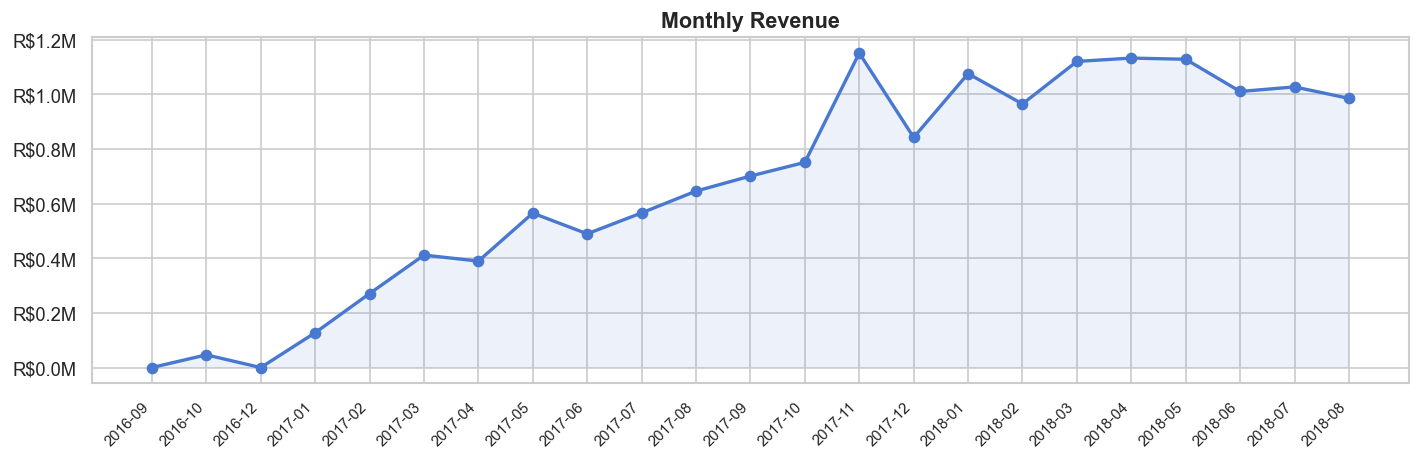

In [17]:
monthly = (
    df.groupby('order_month')['revenue']
    .sum()
    .reset_index()
)
monthly['order_month_str'] = monthly['order_month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['order_month_str'], monthly['revenue'] / 1e6, marker='o', linewidth=2)
ax.fill_between(monthly['order_month_str'], monthly['revenue'] / 1e6, alpha=0.1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'monthly_revenue.png', dpi=150)
plt.show()

### 5.2 Top 10 product categories by revenue

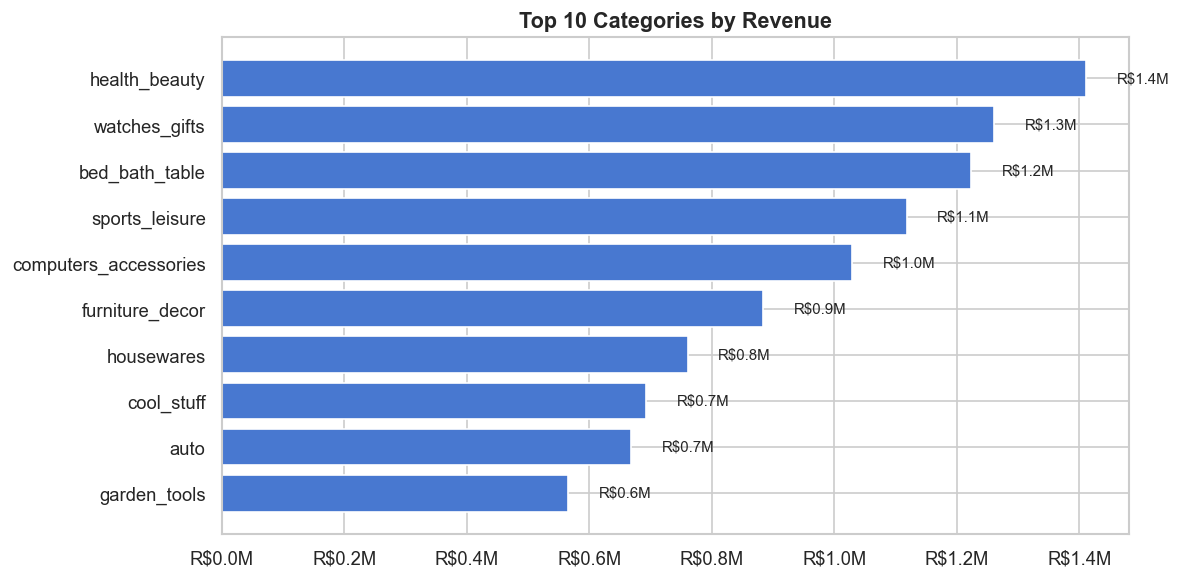

In [18]:
top_cats = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cats['category'][::-1], top_cats['revenue'][::-1] / 1e6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax.set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_cats['revenue'][::-1] / 1e6):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'R${val:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'top_categories.png', dpi=150)
plt.show()

### 5.3 Delivery time distribution

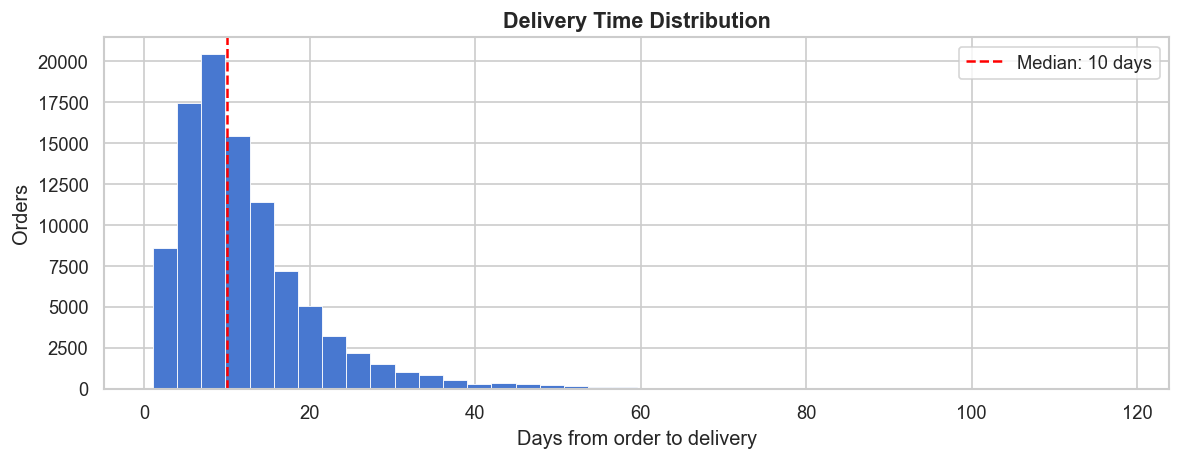

Late delivery rate: 6.7%


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['delivery_days'], bins=40, edgecolor='white', linewidth=0.5)
ax.axvline(df['delivery_days'].median(), color='red', linestyle='--', label=f'Median: {df["delivery_days"].median():.0f} days')
ax.set_xlabel('Days from order to delivery')
ax.set_ylabel('Orders')
ax.set_title('Delivery Time Distribution', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'delivery_distribution.png', dpi=150)
plt.show()

late_pct = df['is_late'].mean() * 100
print(f'Late delivery rate: {late_pct:.1f}%')

### 5.4 Review score distribution

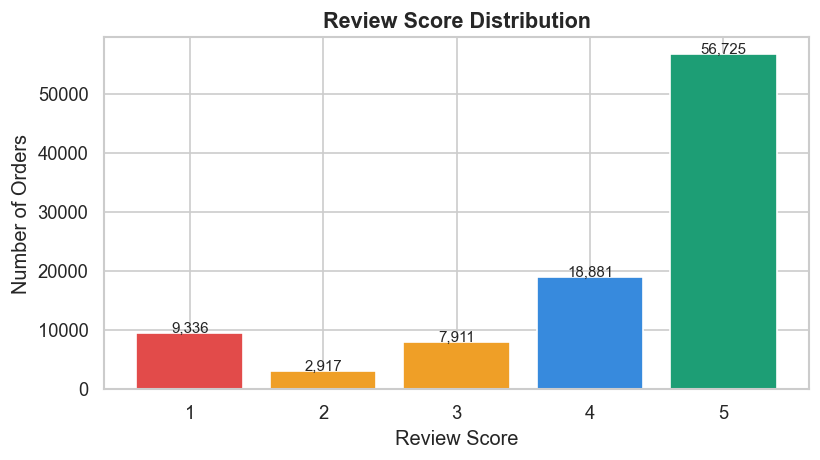

NPS proxy: 38.2


In [20]:
score_counts = df['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E24B4A','#EF9F27','#EF9F27','#378ADD','#1D9E75']
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Orders')
ax.set_title('Review Score Distribution', fontsize=13, fontweight='bold')
for i, (score, count) in enumerate(score_counts.items()):
    ax.text(score, count + 200, f'{count:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'review_scores.png', dpi=150)
plt.show()

nps_counts = df['nps_segment'].value_counts()
promoters  = nps_counts.get('promoter', 0)
detractors = nps_counts.get('detractor', 0)
total_rated = df['review_score'].notna().sum()
nps = ((promoters - detractors) / total_rated) * 100
print(f'NPS proxy: {nps:.1f}')

### 5.5 Revenue by customer state (top 10)

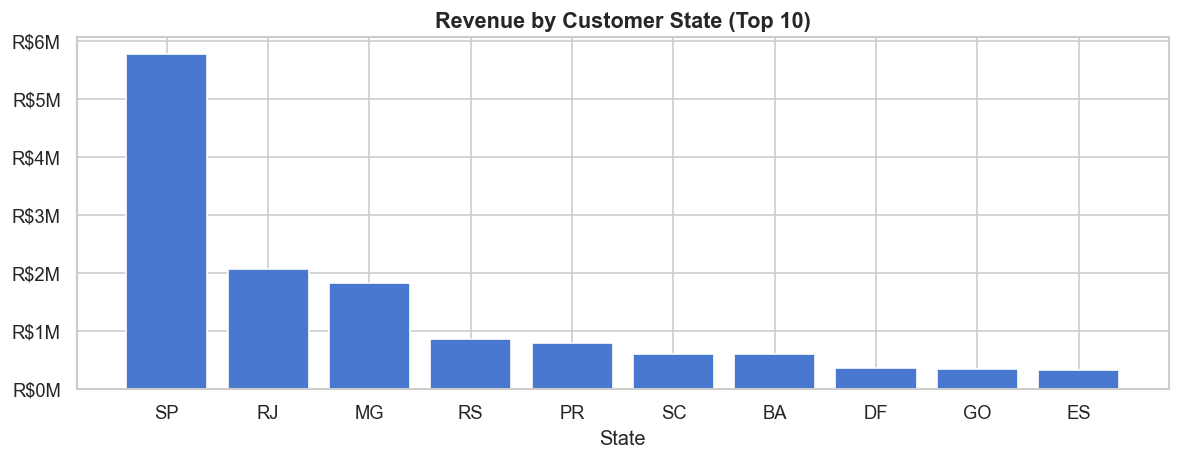

In [21]:
state_rev = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(state_rev['customer_state'], state_rev['revenue'] / 1e6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}M'))
ax.set_title('Revenue by Customer State (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
plt.tight_layout()
plt.savefig(OUT / 'revenue_by_state.png', dpi=150)
plt.show()

### 5.6 Repeat vs one-time customers

                    num_orders  avg_revenue  total_revenue
is_repeat_customer                                        
One-time                 90493       160.70  14,542,159.06
Repeat                    5921       145.98     864,357.21


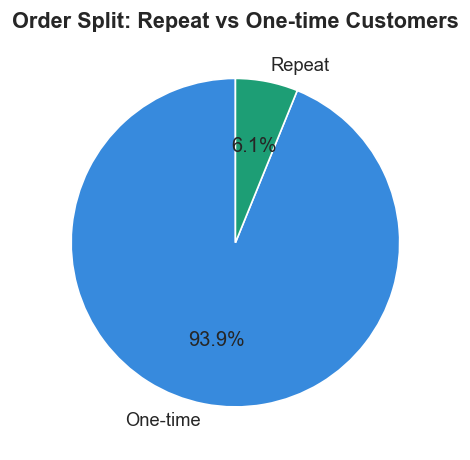

In [22]:
repeat_summary = df.groupby('is_repeat_customer').agg(
    num_orders    = ('order_id', 'count'),
    avg_revenue   = ('revenue', 'mean'),
    total_revenue = ('revenue', 'sum')
).rename(index={True: 'Repeat', False: 'One-time'})

print(repeat_summary)

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['One-time', 'Repeat']
values = repeat_summary.loc[['One-time', 'Repeat'], 'num_orders']
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90,
       colors=['#378ADD', '#1D9E75'])
ax.set_title('Order Split: Repeat vs One-time Customers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'repeat_customers.png', dpi=150)
plt.show()

## 6. Summary statistics (for the README)

In [23]:
print('=== KEY METRICS ===')
print(f"Total orders:          {len(df):,}")
print(f"Total revenue:         R${df['revenue'].sum():,.0f}")
print(f"Avg order value:       R${df['revenue'].mean():,.2f}")
print(f"Avg delivery time:     {df['delivery_days'].mean():.1f} days")
print(f"Late delivery rate:    {df['is_late'].mean()*100:.1f}%")
print(f"NPS proxy:             {nps:.1f}")
print(f"Repeat customer rate:  {df['is_repeat_customer'].mean()*100:.1f}%")
print(f"Unique customers:      {df['customer_unique_id'].nunique():,}")
print(f"Unique product cats:   {df['category'].nunique()}")

=== KEY METRICS ===
Total orders:          96,414
Total revenue:         R$15,406,516
Avg order value:       R$159.80
Avg delivery time:     12.0 days
Late delivery rate:    6.7%
NPS proxy:             38.2
Repeat customer rate:  6.1%
Unique customers:      93,294
Unique product cats:   72
